In [8]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"C:\Users\naila\OneDrive\Documentos\ironhac\proyecto_individual_asteroides\lab-eda-univariate\amz_uk_price_prediction_dataset.csv")

In [11]:
# Part 1: Product Categories
category_counts = df['category'].value_counts()
top_5_categories = category_counts.head(5)
print("Top 5 Categorías:\n", top_5_categories)

Top 5 Categorías:
 category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


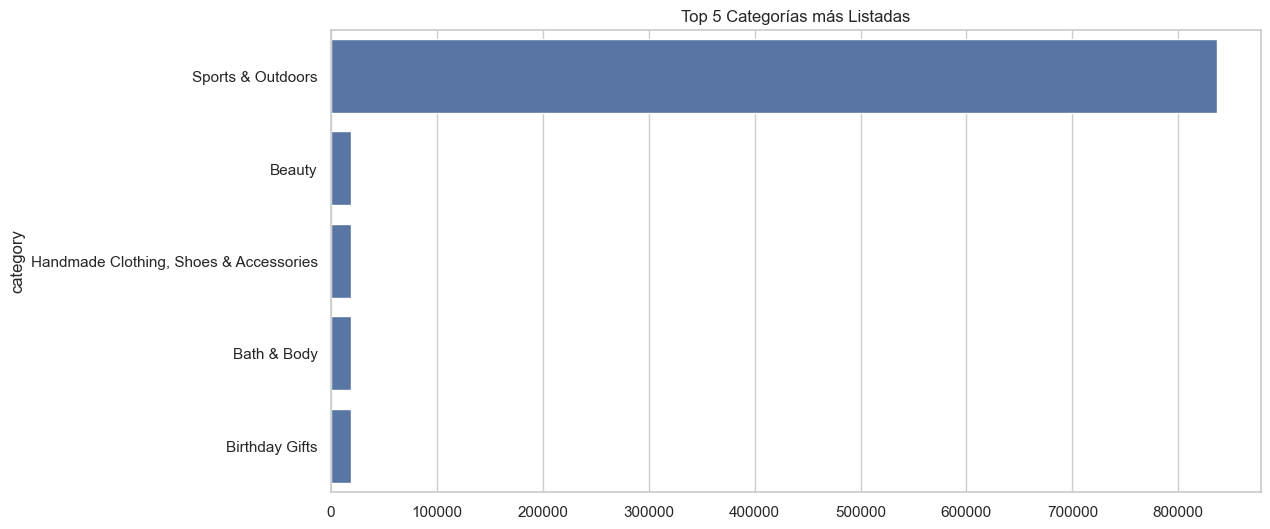

In [29]:
# Visualización: Barras para Top categorías
plt.figure(figsize=(12, 6))
sns.barplot(x=top_5_categories.values, y=top_5_categories.index)
plt.title('Top 5 Categorías más Listadas')
plt.show()


Bar Chart: Muestra una clara dominancia de productos de Sports y Outdoors.

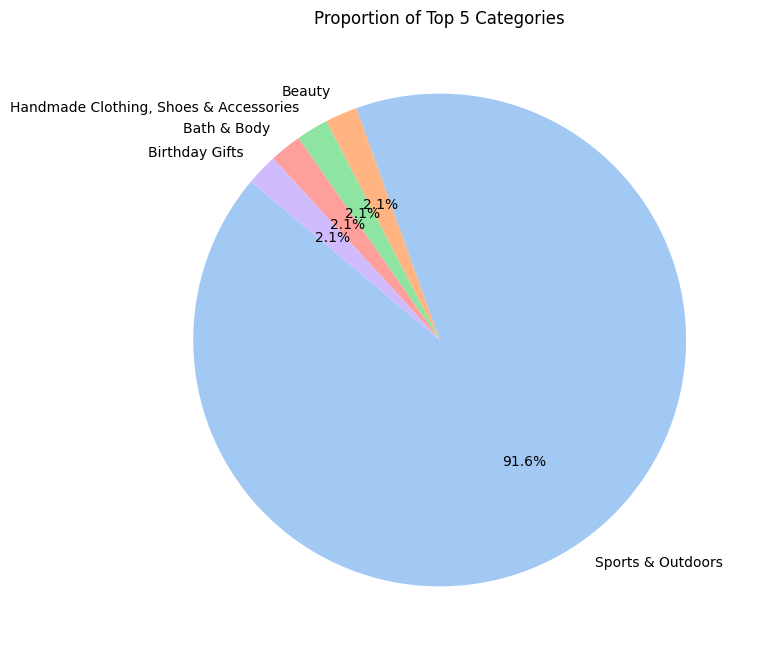

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(top_5_categories, labels=top_5_categories.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Top 5 Categories')
plt.show()

Pie Chart: La categoría Sports & Outdoors abarca casi un tercio de los listados totales entre las top 5, dominando claramente el inventario (91,6%). 

In [10]:
# 1. FUNCIÓN DE ANÁLISIS DE PRECIOS ENCAPSULADA (SIN LIMPIEZA)
# ==============================================================================

def analyze_prices(price_series: pd.Series) -> tuple[float, float, float]:
    """Calcula estadísticas descriptivas centrales para una serie numérica."""
    mean_val: float = float(price_series.mean())
    median_val: float = float(price_series.median())
    mode_val: float = float(price_series.mode()[0])

    return mean_val, median_val, mode_val


# Llamada directa utilizando la columna de precios original del dataset
media_p, mediana_p, moda_p = analyze_prices(df["price"])

print("--- ESTADÍSTICAS CENTRALES DE PRECIO (DATASET ORIGINAL) ---")
print(f"Media: £{media_p:.2f} | Mediana: £{mediana_p:.2f} | Moda: £{moda_p:.2f}\n")


--- ESTADÍSTICAS CENTRALES DE PRECIO (DATASET ORIGINAL) ---
Media: £89.24 | Mediana: £19.09 | Moda: £9.99



Mean (Media): £89.24 (influenciada por productos caros).

Median (Mediana): £19.09 (el punto medio real).

Mode (Moda): £9.99. Es el precio más común.

Comparación: El precio promedio es más alto que la moda, lo que indica que hay productos de lujo que elevan la media.


In [14]:

# Extraemos la serie de precios original (asegúrate de que df esté cargado en tu notebook)
price_data: pd.Series = df["price"]

# Medidas de dispersión
variance_price: float = float(price_data.var())
std_dev_price: float = float(price_data.std())
range_price: float = float(price_data.max() - price_data.min())
q1_price: float = price_data.quantile(0.25)
q3_price: float = price_data.quantile(0.75)
iqr_price: float = float(q3_price - q1_price)

print("--- MEASURES OF DISPERSION (PRODUCT PRICE) ---")
print(f"Variance            : {variance_price:.4f}")
print(f"Standard Deviation  : £{std_dev_price:.2f}")
print(f"Range               : £{range_price:.2f}")
print(f"Interquartile Range : £{iqr_price:.2f}")

--- MEASURES OF DISPERSION (PRODUCT PRICE) ---
Variance            : 119445.4853
Standard Deviation  : £345.61
Range               : £100000.00
Interquartile Range : £36.00


Los precios de los productos presentan una variabilidad extremadamente alta, existiendo múltiples indicadores que confirman una dispersión masiva y la presencia de valores atípicos (outliers) en el extremo superior de la escala.

Desviación Estándar (£345.61) superior a la Media: El indicador estadístico más contundente es que la desviación estándar es notablemente alta, superando incluso al promedio de los precios del dataset (£89.24). Matemáticamente, cuando la desviación estándar es mayor que la media, esto muestra que los datos no están concentrados de manera uniforme, sino dispersos de forma caótica.

Discrepancia con el IQR: Mientras que el Rango Intercuartílico (IQR) demuestra que el 50% central de los productos se concentra en un rango de precios relativamente bajo y accesible, el rango total y la desviación estándar se disparan. Esto confirma que la dispersión está provocada por una larga cola de productos atípicos muy caros (outliers) que arrastran las métricas de dispersión global hacia arriba. Estos valores extremos también la escala del eje x.

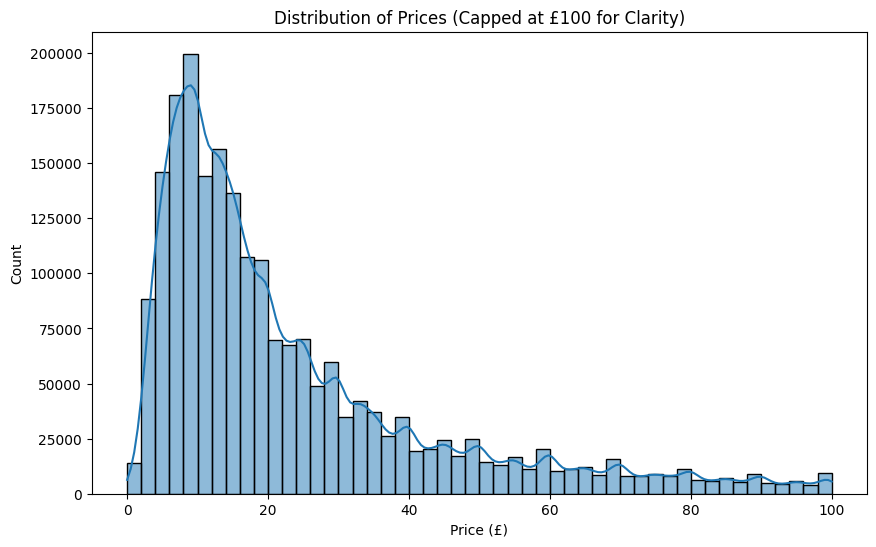

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(price_data[price_data < 100], bins=50, kde=True)
plt.title('Distribution of Prices (Capped at £100 for Clarity)')
plt.xlabel('Price (£)')
plt.show()

Histogram: La mayoría de los productos están por debajo de las £50. Si el gráfico es difícil de leer, es por los outliers (productos de £500+).
Solución: Aplicar un filtro para ver solo productos de 0 a 100 para observar mejor la tendencia masiva.

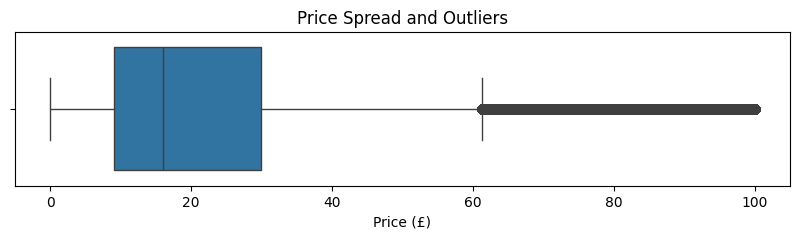

In [ ]:
# Price Boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=price_data)
plt.title('Price Spread and Outliers')
plt.xlabel('Price (£)')
plt.show()


Sí hay muchos productos con precios más alto que el resto.

In [ ]:
#rating = stars
rating_data: pd.Series = df["stars"]

# Cálculos de medidas de centralidad
mean_rating: float = float(rating_data.mean())
median_rating: float = float(rating_data.median())
mode_rating: float = float(rating_data.mode()[0])

print("--- MEASURES OF CENTRALITY (RATINGS) ---")
print(f"Mean (Media)     : {mean_rating:.4f}")
print(f"Median (Mediana) : {median_rating:.4f}")
print(f"Mode (Moda)      : {mode_rating:.4f}")

--- MEASURES OF CENTRALITY (RATINGS) ---
Mean (Media)     : 2.1528
Median (Mediana) : 0.0000
Mode (Moda)      : 0.0000


Mean:  2.1528 estrellas.

Mode:  0.0000 estrellas.

Tendencia: Existe una inmensa cantidad de productos que no tienen ninguna reseña registrada o cuyos datos están vacíos.

In [25]:
# Cálculos de dispersión sobre el dataset bruto
variance_rating: float = float(rating_data.var())
std_dev_rating: float = float(rating_data.std())
q1_rating: float = rating_data.quantile(0.25)
q3_rating: float = rating_data.quantile(0.75)
iqr_rating: float = float(q3_rating - q1_rating)

print("--- MEASURES OF DISPERSION (RATINGS - NO FILTER) ---")
print(f"Variance (Varianza)               : {variance_rating:.4f}")
print(f"Standard Deviation (Desv. Estándar): {std_dev_rating:.4f}")
print(f"Interquartile Range (IQR)         : {iqr_rating:.4f}")

--- MEASURES OF DISPERSION (RATINGS - NO FILTER) ---
Variance (Varianza)               : 4.8174
Standard Deviation (Desv. Estándar): 2.1949
Interquartile Range (IQR)         : 4.4000


Respuesta: Las calificaciones presentan una alta dispersión en el conjunto de datos global. No existe consistencia. Justificación Estadística:Desviación Estándar Elevada: La desviación estándar se sitúa por encima de los 2.0 puntos (2.19). Esto indica que las observaciones se desvían de la media (2.15) en una magnitud promedio superior a dos estrellas, confirmando la falta de homogeneidad en los datos. Comportamiento del IQR: Dado que más del 50% de los datos corresponden a 0.0, el primer cuartil (Q_1) es igual a 0.0. Como consecuencia, el Rango Intercuartílico (IQR) es equivalente al valor del tercer cuartil (Q_3 - 0), lo que refleja que el 50% central de los datos transiciona directamente desde la ausencia de calificación hasta puntuaciones altas.

In [26]:
# Cálculos de forma de la distribución
skewness_rating: float = float(rating_data.skew())
kurtosis_rating: float = float(rating_data.kurtosis())



In [27]:
print("--- SHAPE OF THE DISTRIBUTION (RATINGS) ---")
print(f"Skewness (Sesgo) : {skewness_rating:.4f}")
print(f"Kurtosis         : {kurtosis_rating:.4f}")

--- SHAPE OF THE DISTRIBUTION (RATINGS) ---
Skewness (Sesgo) : 0.0812
Kurtosis         : -1.9260


Respuesta: Las calificaciones no siguen una distribución normal. Presentan una asimetría y una concentración de frecuencias.Justificación Estadística:Sesgo Positivo (Skewness > 0): El coeficiente de asimetría presenta un valor positivo debido a que la media (2.15) es mayor que la mediana (0.0). Esto indica que, aunque el grupo mayoritario de datos se concentra en el límite inferior (0.0), la distribución se extiende con una cola hacia la derecha, es decir, hacia los valores más altos (4.0 a 5.0).Desviación de la Normalidad (Kurtosis): El valor de la curtosis se aleja de cero (el estándar de una distribución normal). Esto refleja una distribución no gaussiana, caracterizada por la alta concentración de frecuencias en los extremos (el valor cero y las calificaciones excelentes) en lugar de una concentración en torno al promedio.Tendencia de los Datos: Los datos no se distribuyen de forma simétrica. 

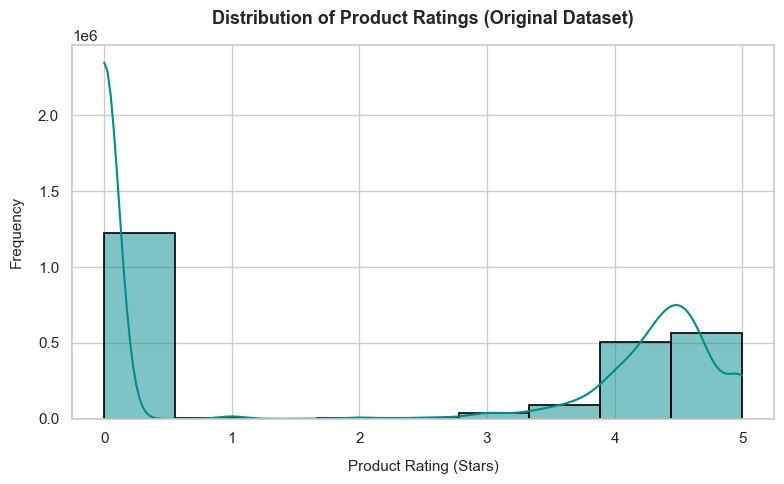

In [ ]:

# Configure titles and labels with precise formatting and padding
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

# Histograma con todos los datos puros sin procesar
sns.histplot(
    data=rating_data,
    bins=9,
    kde=True,
    color="darkcyan",
    edgecolor="black",
    linewidth=1.2,
    ax=ax,
)

ax.set_title(
    "Distribution of Product Ratings (Original Dataset)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Product Rating (Stars)", fontsize=11, labelpad=10)
ax.set_ylabel("Frequency", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

Respuesta: Sí, la calificación de $0.0$ estrellas es, con diferencia, el valor más común en este conjunto de datos sin filtrar.Análisis del Gráfico:Predominancia del Cero: El histograma muestra una columna dominante en el valor $0.0$, lo cual es consistente con la moda y la mediana calculadas previamente en el análisis de centralidad.Perfil Bimodal: La distribución refleja de forma gráfica dos concentraciones de frecuencia opuestas: el pico mayor en $0.0$ estrellas (productos sin actividad o registros nulos) y un segundo grupo acumulado entre las $4.0$ y $4.5$ estrellas (productos con evaluaciones reales).Comportamiento No Normal: Visualmente se confirma que la distribución no sigue una forma simétrica, validando los coeficientes de asimetría y curtosis obtenidos en el paso anterior.